# Prognose mot faktiske FPL-poeng

Velg **sesong, Gameweek og prognosetidspunkt**. Tabellen viser hva modellen forventet, faktiske poeng, minutter, mål, assists og bonus. Grafer og feilmetrikker viser hvor modellen traff og bommet.

Kjør **Run All** med prosjektets `.venv` som Python-kjerne. Notebooken leser lokale snapshots, uten API-kall eller ny modelltrening. Standardvalget er siste runde med ferdige resultater og siste lagrede prognose før fristen.

- **Modellpoeng** er den opprinnelige lagrede prognosen.
- **App-poeng** rekonstruerer modellpoeng × tilgjengelighetsfaktor fra samme snapshots skadeflagg, med dagens appformel. Dette er ikke en logg av en bestemt brukers appøkt.
- **Avvik = prognose − faktisk**. Positivt betyr at modellen overvurderte spilleren.
- Faktiske poeng er offisielle spillerpoeng, uten kapteinsdobling, benkeeffekt eller transferhits. Dobbelrunder summeres.
- Kun runder merket `finished` og `data_checked` evalueres. Manglende historikk holdes utenfor metrikker og blir aldri erstattet med null. En tilgjengelig spillerhistorikk uten kamper i en ferdig runde gir 0 poeng.

En sammenligning av én runde sier lite alene om langsiktig modellkvalitet.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, Markdown, clear_output

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'src/capture_fpl.py').exists())
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))
from forecast_comparison import catalog, compare, metrics, outcome_source

pd.set_option('display.max_colwidth', 70)
plt.rcParams.update({'figure.figsize': (12, 5), 'axes.spines.top': False, 'axes.spines.right': False})
CATALOG = catalog(ROOT)
if CATALOG.empty:
    raise ValueError('Ingen gyldige lokale prognoser. Kjør src/capture_fpl.py først.')
rounds = CATALOG[['season', 'GW']].drop_duplicates().copy()
rounds['resultat klart'] = [outcome_source(ROOT, r.season, r.GW)[1] is not None for r in rounds.itertuples()]
display(rounds.reset_index(drop=True))

,season,GW,resultat klart
0,2026-27,4,True
1,2026-27,5,True
2,2026-27,6,False
3,2026-27,7,False
4,2026-27,8,False
5,2026-27,9,False
6,2026-27,10,False
7,2026-27,11,False
8,2026-27,12,False
9,2026-27,13,False


## Sammenligning per spiller

Velg rå modellpoeng eller app-poeng som evalueringsgrunnlag. Posisjon og navnesøk filtrerer både tabellen og grafene; «antall rader» begrenser bare visningen. Tabellen sorteres etter valgt felt. CSV-eksporten inneholder alle spillerne i valgt snapshot.

Hele spillerregisteret inneholder mange reserver med 0 minutter. Derfor vises også metrikker for de 25 høyest rangerte spillerne, valgt **etter prognosen**, ikke etter resultatet.

In [2]:
ready = rounds[rounds['resultat klart']]
default = (ready if len(ready) else rounds).iloc[-1]
season_widget = widgets.Dropdown(options=sorted(CATALOG.season.unique()), value=default.season, description='Sesong:')
gw_widget = widgets.Dropdown(description='Gameweek:')
snapshot_widget = widgets.Dropdown(description='Prognose:', layout=widgets.Layout(width='95%'), style={'description_width': 'initial'})
score_widget = widgets.Dropdown(options=[('Modellpoeng', 'prediction'), ('App-poeng (skadejustert)', 'app_prediction')], description='Poeng:')
position_widget = widgets.Dropdown(options=['Alle', 'GK', 'DEF', 'MID', 'FWD'], description='Posisjon:')
search_widget = widgets.Text(description='Spiller:', placeholder='Søk på navn')
sort_widget = widgets.Dropdown(options=[('Høyest prognose', 'score'), ('Høyest faktiske poeng', 'actual_points'), ('Størst bom', 'abs_error'), ('Mest overvurdert', 'error'), ('Mest undervurdert', 'under')], description='Sorter:')
limit_widget = widgets.IntSlider(value=30, min=10, max=100, step=10, description='Antall rader:')
export_button = widgets.Button(description='Eksporter valgt GW til CSV', icon='download')
output = widgets.Output()
export_output = widgets.Output()

def set_snapshots(*_):
    subset = CATALOG[(CATALOG.season == season_widget.value) & (CATALOG.GW == gw_widget.value)]
    options = [(f"{r.forecast_at.tz_convert('Europe/Oslo'):%d.%m.%Y %H:%M:%S} | {r.model} | {r.snapshot}", i) for i, r in subset.iterrows()]
    snapshot_widget.options = options
    if options:
        snapshot_widget.value = options[-1][1]

def set_gameweeks(*_):
    gw_widget.options = sorted(CATALOG.loc[CATALOG.season.eq(season_widget.value), 'GW'].unique())
    gw_widget.value = int(default.GW) if default.GW in gw_widget.options else gw_widget.options[-1]
    set_snapshots()

set_gameweeks()

def selected_comparison():
    return compare(ROOT, CATALOG.loc[snapshot_widget.value])

def render(*_):
    if snapshot_widget.value is None:
        return
    with output:
        clear_output(wait=True)
        record = CATALOG.loc[snapshot_widget.value]
        full = selected_comparison()
        frame = full.copy()
        if position_widget.value != 'Alle':
            frame = frame[frame.position.eq(position_widget.value)]
        if search_widget.value.strip():
            frame = frame[frame.name.str.contains(search_widget.value.strip(), case=False, regex=False, na=False)]
        score = score_widget.value
        display(Markdown(f"**{record.season} · GW{record.GW}** — prognose {record.forecast_at.tz_convert('Europe/Oslo'):%d.%m.%Y %H:%M}, frist {record.deadline.tz_convert('Europe/Oslo'):%d.%m.%Y %H:%M} (norsk tid)."))
        print('Prognosefil:', Path(record.forecast_file).relative_to(ROOT))
        print('Resultatkilde:', full.attrs.get('outcome_source') or 'Venter på ferdig, kontrollert runde')
        print('Resultater observert:', full.attrs.get('labels_observed_at') or '—')
        if frame.empty:
            display(Markdown('Ingen spillere matcher filteret.'))
            return
        top = frame.sort_values([score, 'player_id'], ascending=[False, True]).head(25)
        report = pd.DataFrame([metrics(frame, score), metrics(top, score)], index=['Alle i filter', 'Topp 25 etter prognose'])
        display(report.round(3))
        frame['score'] = frame[score]
        frame['error'] = frame.score - frame.actual_points
        frame['abs_error'] = frame.error.abs()
        frame['under'] = -frame.error
        valid = frame.dropna(subset=['score', 'actual_points'])
        if valid.empty:
            display(Markdown('**Venter på resultat.** Prognoser vises, men runden evalueres ikke ennå.'))
        else:
            fig, axes = plt.subplots(1, 2, figsize=(14, 5))
            for pos, group in valid.groupby('position'):
                axes[0].scatter(group.score, group.actual_points, label=pos, alpha=.55, s=25)
            lo = min(0, valid.score.min(), valid.actual_points.min())
            hi = max(1, valid.score.max(), valid.actual_points.max()) + 1
            axes[0].plot([lo, hi], [lo, hi], '--', color='gray', label='Perfekt treff')
            axes[0].set(xlabel='Prognose', ylabel='Faktiske FPL-poeng', title='Prognose mot faktisk')
            axes[0].legend()
            shown = frame.sort_values(['score', 'player_id'], ascending=[False, True]).head(15).iloc[::-1]
            y = np.arange(len(shown))
            axes[1].barh(y-.2, shown.score, height=.4, label='Prognose')
            axes[1].barh(y+.2, shown.actual_points, height=.4, label='Faktisk')
            axes[1].set(yticks=y, yticklabels=shown.name, xlabel='Poeng', title='15 høyest rangerte før runden')
            axes[1].legend()
            fig.tight_layout()
            plt.show()
            plt.close(fig)
        columns = ['player_id', 'name', 'team', 'position', 'prediction', 'app_prediction', 'actual_points', 'error', 'actual_minutes', 'goals', 'assists', 'bonus', 'clean_sheets', 'status_at_forecast', 'outcome_status']
        display(frame.sort_values([sort_widget.value, 'player_id'], ascending=[False, True], na_position='last')[columns].head(limit_widget.value).round(2).reset_index(drop=True))
        display(Markdown('`error` følger poengtypen valgt over. `status_at_forecast`: a=tilgjengelig, d=usikker, i=skadet, s=suspendert, u=utilgjengelig.'))

def export_csv(_):
    record = CATALOG.loc[snapshot_widget.value]
    destination = ROOT / 'artifacts/forecast_comparisons' / f"{record.season}_GW{record.GW}_{record.snapshot}.csv"
    destination.parent.mkdir(parents=True, exist_ok=True)
    data = selected_comparison()
    data['forecast_at'] = record.forecast_at.isoformat()
    data['snapshot'] = record.snapshot
    data['labels_observed_at'] = data.attrs.get('labels_observed_at')
    data.to_csv(destination, index=False)
    with export_output:
        clear_output()
        print('Lagret:', destination)

season_widget.observe(set_gameweeks, names='value')
gw_widget.observe(set_snapshots, names='value')
for control in [snapshot_widget, score_widget, position_widget, search_widget, sort_widget, limit_widget]:
    control.observe(render, names='value')
export_button.on_click(export_csv)
display(widgets.VBox([widgets.HBox([season_widget, gw_widget]), snapshot_widget, widgets.HBox([score_widget, position_widget]), widgets.HBox([search_widget, sort_widget]), limit_widget, export_button, export_output, output]))
render()

## Utvikling på tvers av ferdige runder

Én prognose per Gameweek: den sist lagrede før fristen. Modellen kan ha endret seg mellom rundene; modellnavnet vises derfor i tabellen. Dette er evaluering av faktisk lagrede prognoser, ikke en kontrollert sammenligning av samme modell over tid. Tabellen under bruker alltid **rå modellpoeng**, uavhengig av valget over.

,season,GW,model,snapshot,players,evaluated,missing,MAE,RMSE,bias,predicted_mean,actual_mean
0,2026-27,4,legacy,capture_20260910T032832Z_8m_l41xw,654,654,0,1.179,2.173,-0.174,1.234,1.408
1,2026-27,5,market_hgb+market_fallback+minutes_mixture_15+quantile_hgb,capture_20260918T160900Z_rescore_ks0tcs_u,659,659,0,1.137,2.181,-0.196,1.268,1.464


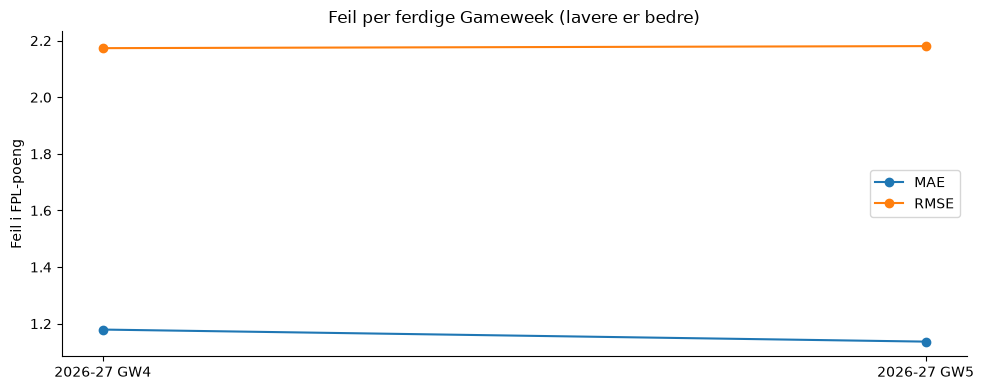

In [3]:
summary_rows = []
for (season, gw), group in CATALOG.groupby(['season', 'GW']):
    record = group.sort_values('forecast_at').iloc[-1]
    if outcome_source(ROOT, season, gw)[1] is None:
        continue
    comparison = compare(ROOT, record)
    summary_rows.append({'season': season, 'GW': gw, 'model': record.model, 'snapshot': record.snapshot, **metrics(comparison)})
summary = pd.DataFrame(summary_rows)
if summary.empty:
    print('Ingen ferdige runder med lokale prognoser og kontrollerte resultater ennå.')
else:
    display(summary.round(3))
    fig, ax = plt.subplots(figsize=(10, 4))
    x = summary.season + ' GW' + summary.GW.astype(str)
    ax.plot(x, summary.MAE, marker='o', label='MAE')
    ax.plot(x, summary.RMSE, marker='o', label='RMSE')
    ax.set(ylabel='Feil i FPL-poeng', title='Feil per ferdige Gameweek (lavere er bedre)')
    ax.legend()
    fig.tight_layout()
    plt.show()
    plt.close(fig)

## Når nye resultater kommer

Kjør `.venv/bin/python src/capture_fpl.py` fra prosjektroten etter at runden er ferdig, og kjør notebooken på nytt. Gamle prognoser beholdes, mens neste komplette snapshot gir oppdaterte faktiske poeng. En runde uten en ekte lagret prognose før fristen kan ikke evalueres her.